# Auto MPG — Model Building

Train and compare 7 regression models, run cross-validation, tune the best performer.

## 1. Imports & Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor

import sys
sys.path.append(".")
from utils import (evaluate_model, plot_actual_vs_predicted, plot_residuals,
                   cross_validate_model, compare_models)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

%matplotlib inline

In [2]:
df = pd.read_csv("data/auto_mpg_cleaned.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (398, 13)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,power_to_weight,displacement_per_cyl,is_v8,decade,origin_Japan,origin_USA
0,18.0,8,307.0,130.0,3504.0,12.0,70,37.100457,38.375,1,70,0,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,44.679123,43.750,1,70,0,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,43.655413,39.750,1,70,0,1
3,16.0,8,304.0,150.0,3433.0,12.0,70,43.693562,38.000,1,70,0,1
4,17.0,8,302.0,140.0,3449.0,10.5,70,40.591476,37.750,1,70,0,1


## 2. Train / Test Split + Scaling

In [3]:
X = df.drop(columns=["mpg"])
y = df["mpg"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train mean MPG: {y_train.mean():.2f}, Test mean MPG: {y_test.mean():.2f}")

Train: (318, 12), Test: (80, 12)
Train mean MPG: 23.61, Test mean MPG: 23.14


## 3. Model 1 — Linear Regression


  Linear Regression
  R2    : 0.8807
  RMSE  : 2.5324
  MAE   : 1.9330
  MAPE  : 0.0896


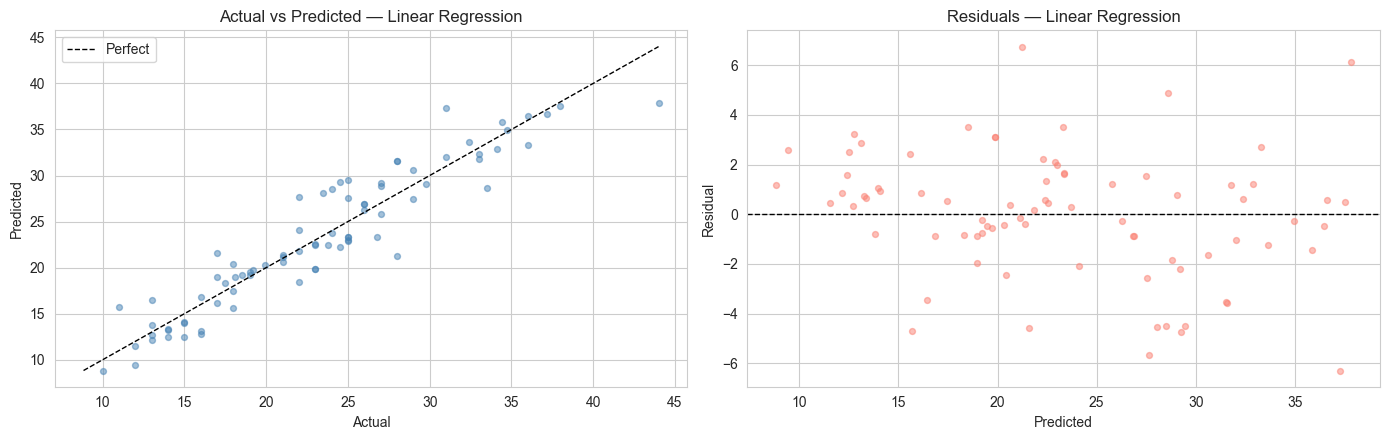

In [4]:
lr = LinearRegression()
lr.fit(X_train_s, y_train)
pred_lr = lr.predict(X_test_s)
m_lr = evaluate_model("Linear Regression", y_test, pred_lr)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
plot_actual_vs_predicted(y_test, pred_lr, "Linear Regression", ax=axes[0])
plot_residuals(y_test, pred_lr, "Linear Regression", ax=axes[1])
plt.tight_layout(); plt.show()

## 4. Model 2 — Ridge


  Ridge
  R2    : 0.8791
  RMSE  : 2.5497
  MAE   : 1.9353
  MAPE  : 0.0919


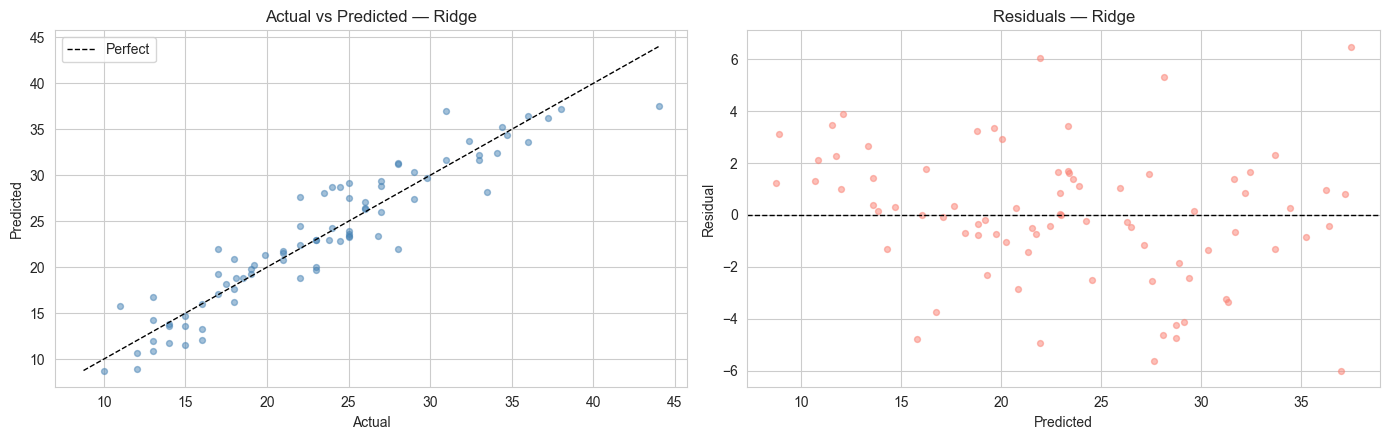

In [5]:
ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_train_s, y_train)
pred_ridge = ridge.predict(X_test_s)
m_ridge = evaluate_model("Ridge", y_test, pred_ridge)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
plot_actual_vs_predicted(y_test, pred_ridge, "Ridge", ax=axes[0])
plot_residuals(y_test, pred_ridge, "Ridge", ax=axes[1])
plt.tight_layout(); plt.show()

## 5. Model 3 — Lasso


  Lasso
  R2    : 0.8584
  RMSE  : 2.7593
  MAE   : 2.1494
  MAPE  : 0.1057


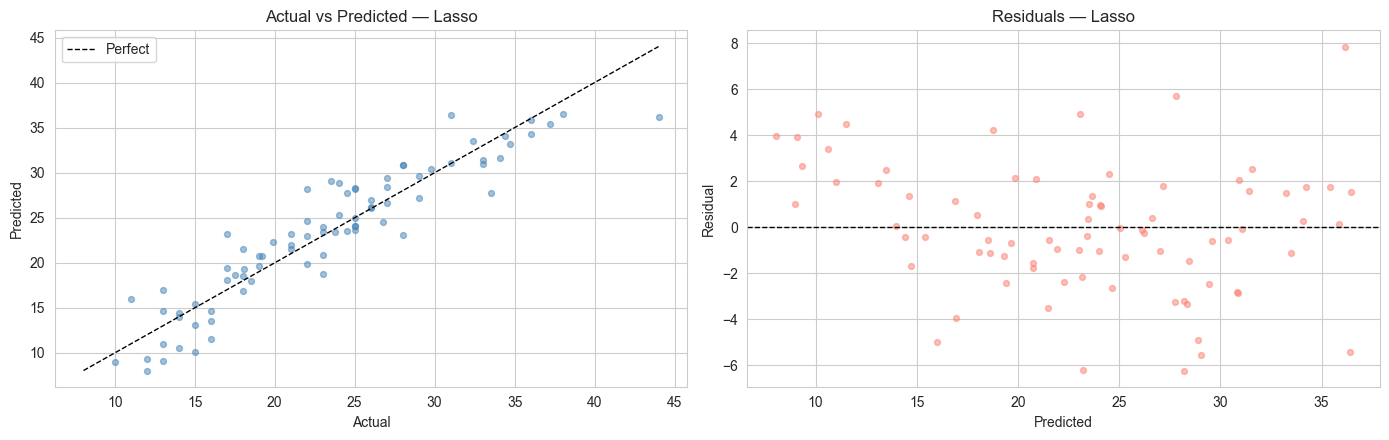

In [6]:
lasso = Lasso(alpha=0.1, random_state=42, max_iter=10000)
lasso.fit(X_train_s, y_train)
pred_lasso = lasso.predict(X_test_s)
m_lasso = evaluate_model("Lasso", y_test, pred_lasso)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
plot_actual_vs_predicted(y_test, pred_lasso, "Lasso", ax=axes[0])
plot_residuals(y_test, pred_lasso, "Lasso", ax=axes[1])
plt.tight_layout(); plt.show()

## 6. Model 4 — Decision Tree


  Decision Tree
  R2    : 0.8475
  RMSE  : 2.8639
  MAE   : 1.9234
  MAPE  : 0.0862


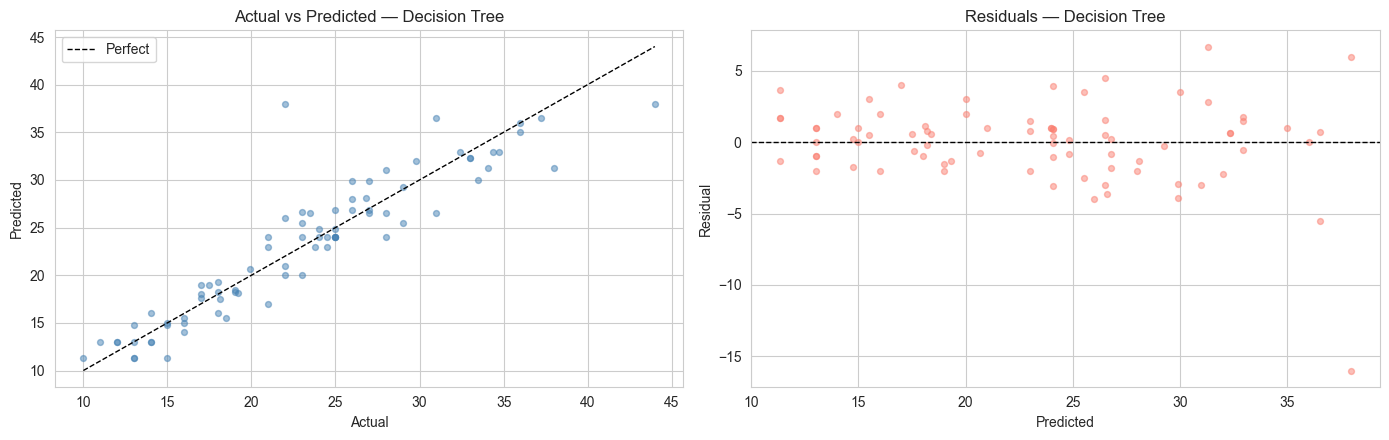

In [7]:
dt = DecisionTreeRegressor(random_state=42, max_depth=8)
dt.fit(X_train, y_train)
pred_dt = dt.predict(X_test)
m_dt = evaluate_model("Decision Tree", y_test, pred_dt)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
plot_actual_vs_predicted(y_test, pred_dt, "Decision Tree", ax=axes[0])
plot_residuals(y_test, pred_dt, "Decision Tree", ax=axes[1])
plt.tight_layout(); plt.show()

## 7. Model 5 — Random Forest


  Random Forest
  R2    : 0.9173
  RMSE  : 2.1087
  MAE   : 1.5876
  MAPE  : 0.0724


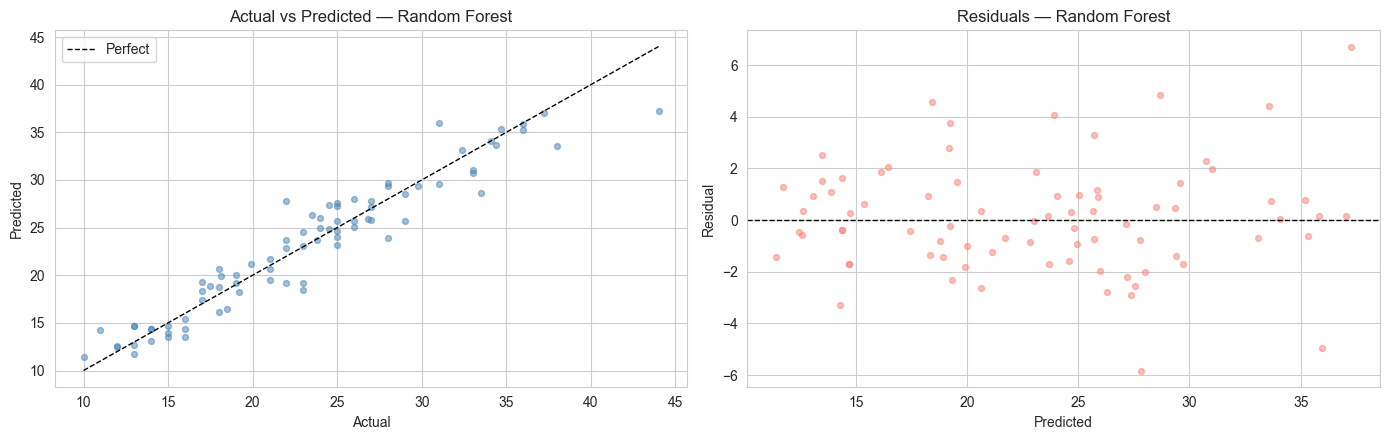

In [8]:
rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
m_rf = evaluate_model("Random Forest", y_test, pred_rf)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
plot_actual_vs_predicted(y_test, pred_rf, "Random Forest", ax=axes[0])
plot_residuals(y_test, pred_rf, "Random Forest", ax=axes[1])
plt.tight_layout(); plt.show()

## 8. Model 6 — Gradient Boosting


  Gradient Boosting
  R2    : 0.9010
  RMSE  : 2.3073
  MAE   : 1.6625
  MAPE  : 0.0764


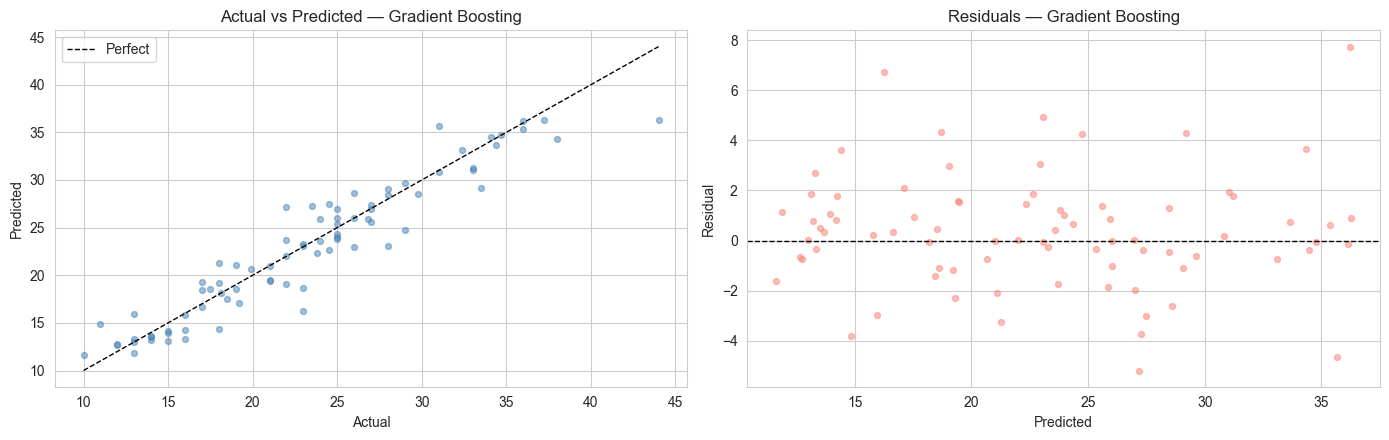

In [9]:
gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)
pred_gb = gb.predict(X_test)
m_gb = evaluate_model("Gradient Boosting", y_test, pred_gb)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
plot_actual_vs_predicted(y_test, pred_gb, "Gradient Boosting", ax=axes[0])
plot_residuals(y_test, pred_gb, "Gradient Boosting", ax=axes[1])
plt.tight_layout(); plt.show()

## 9. Model 7 — KNN (with K optimization)

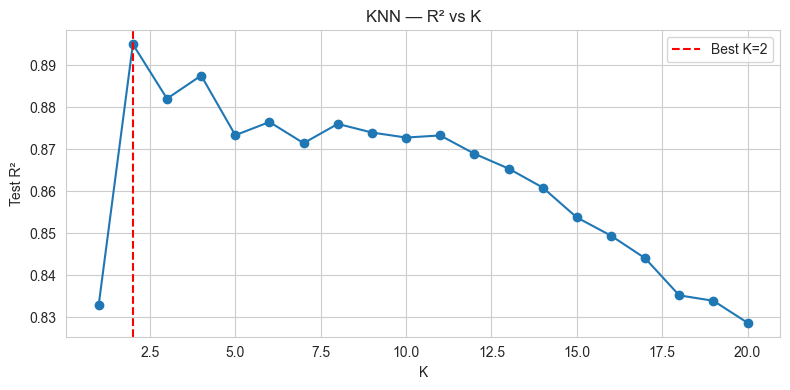


  KNN (K=2)
  R2    : 0.8949
  RMSE  : 2.3768
  MAE   : 1.8300
  MAPE  : 0.0850


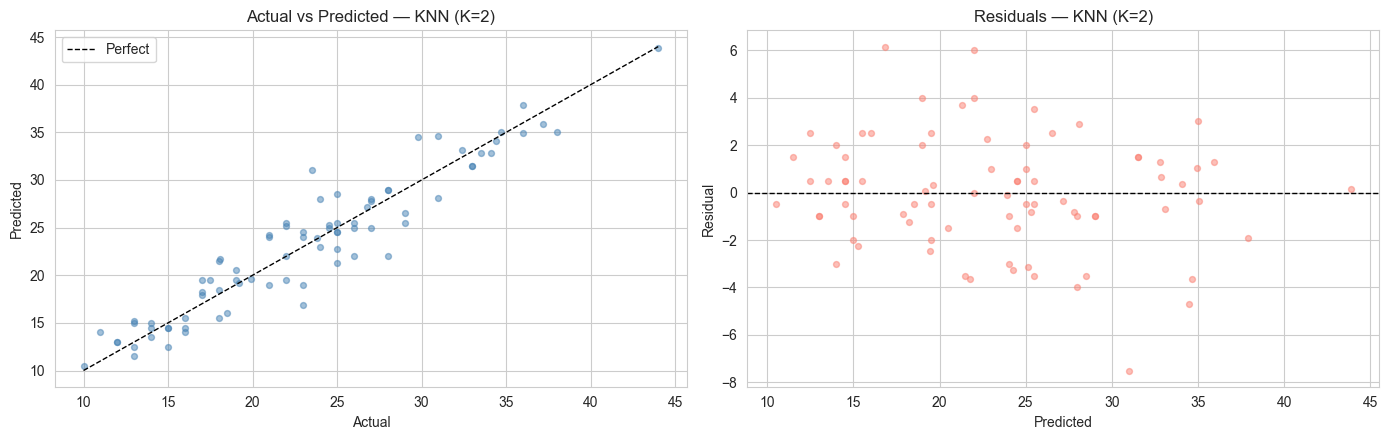

In [10]:
ks = list(range(1, 21))
r2s = []
for k in ks:
    kk = KNeighborsRegressor(n_neighbors=k)
    kk.fit(X_train_s, y_train)
    r2s.append(kk.score(X_test_s, y_test))
best_k = ks[int(np.argmax(r2s))]
plt.figure(figsize=(8, 4))
plt.plot(ks, r2s, marker="o")
plt.axvline(best_k, color="red", linestyle="--", label=f"Best K={best_k}")
plt.xlabel("K"); plt.ylabel("Test R²"); plt.title("KNN — R² vs K")
plt.legend(); plt.tight_layout(); plt.show()

knn = KNeighborsRegressor(n_neighbors=best_k)
knn.fit(X_train_s, y_train)
pred_knn = knn.predict(X_test_s)
m_knn = evaluate_model(f"KNN (K={best_k})", y_test, pred_knn)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
plot_actual_vs_predicted(y_test, pred_knn, f"KNN (K={best_k})", ax=axes[0])
plot_residuals(y_test, pred_knn, f"KNN (K={best_k})", ax=axes[1])
plt.tight_layout(); plt.show()

## 10. Feature Importance (tree-based)

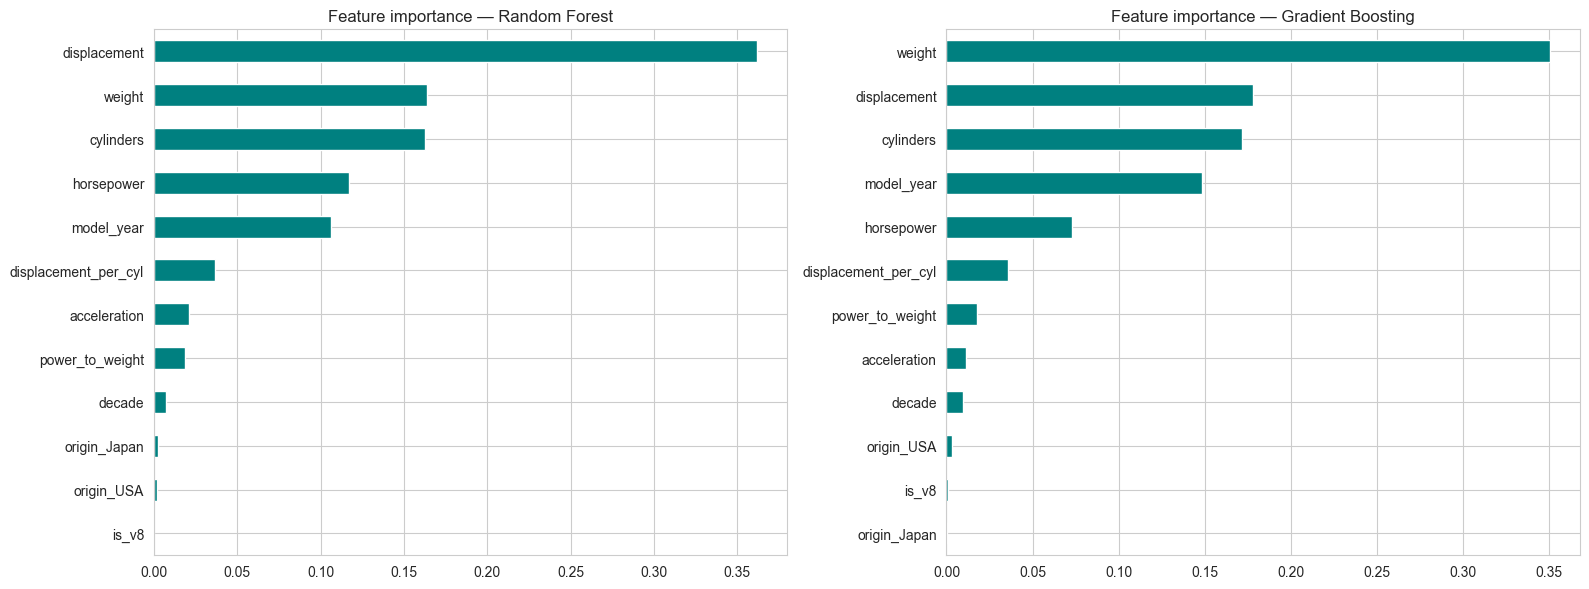

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, model, name in [(axes[0], rf, "Random Forest"), (axes[1], gb, "Gradient Boosting")]:
    imp = pd.Series(model.feature_importances_, index=X.columns).sort_values()
    imp.plot(kind="barh", ax=ax, color="teal")
    ax.set_title(f"Feature importance — {name}")
plt.tight_layout(); plt.show()

## 11. Model Comparison

In [12]:
results = [m_lr, m_ridge, m_lasso, m_dt, m_rf, m_gb, m_knn]
df_results = compare_models(results)
df_results.round(4)

,Model,R2,RMSE,MAE,MAPE
0,Random Forest,0.9173,2.1087,1.5876,0.0724
1,Gradient Boosting,0.9010,2.3073,1.6625,0.0764
2,KNN (K=2),0.8949,2.3768,1.8300,0.0850
3,Linear Regression,0.8807,2.5324,1.9330,0.0896
4,Ridge,0.8791,2.5497,1.9353,0.0919
5,Lasso,0.8584,2.7593,2.1494,0.1057
6,Decision Tree,0.8475,2.8639,1.9234,0.0862


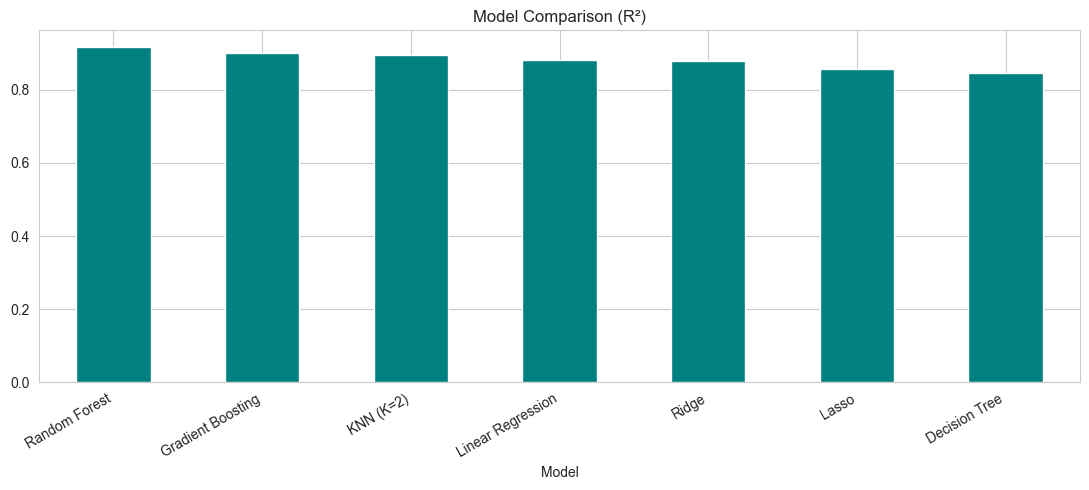

In [13]:
fig, ax = plt.subplots(figsize=(11, 5))
df_results.set_index("Model")[["R2"]].plot(kind="bar", ax=ax, color="teal", legend=False)
ax.set_title("Model Comparison (R²)")
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

## 12. 5-Fold Cross-Validation

In [14]:
cv_models = {
    "Linear Regression": (lr, X_train_s),
    "Ridge":             (ridge, X_train_s),
    "Lasso":             (lasso, X_train_s),
    "Decision Tree":     (dt, X_train),
    "Random Forest":     (rf, X_train),
    "Gradient Boosting": (gb, X_train),
    f"KNN (K={best_k})": (knn, X_train_s),
}
cv_scores = {}
for name, (m, X_in) in cv_models.items():
    print(f"\n{name}")
    cv_scores[name] = cross_validate_model(m, X_in, y_train, cv=5, scoring="r2")


Linear Regression
  CV r2 : [0.8712 0.8445 0.8358 0.8505 0.8352]
  Mean      : 0.8474 (+/- 0.0132)

Ridge
  CV r2 : [0.8664 0.8475 0.8378 0.8422 0.8322]
  Mean      : 0.8452 (+/- 0.0117)

Lasso
  CV r2 : [0.8444 0.8332 0.8269 0.8196 0.8329]
  Mean      : 0.8314 (+/- 0.0082)

Decision Tree
  CV r2 : [0.7905 0.7836 0.8194 0.7053 0.7268]
  Mean      : 0.7651 (+/- 0.0424)

Random Forest


  CV r2 : [0.8789 0.8556 0.8509 0.7777 0.871 ]
  Mean      : 0.8468 (+/- 0.0360)

Gradient Boosting


  CV r2 : [0.8802 0.82   0.8638 0.7911 0.8825]
  Mean      : 0.8475 (+/- 0.0360)

KNN (K=2)
  CV r2 : [0.8338 0.8128 0.8177 0.7501 0.7806]
  Mean      : 0.7990 (+/- 0.0299)


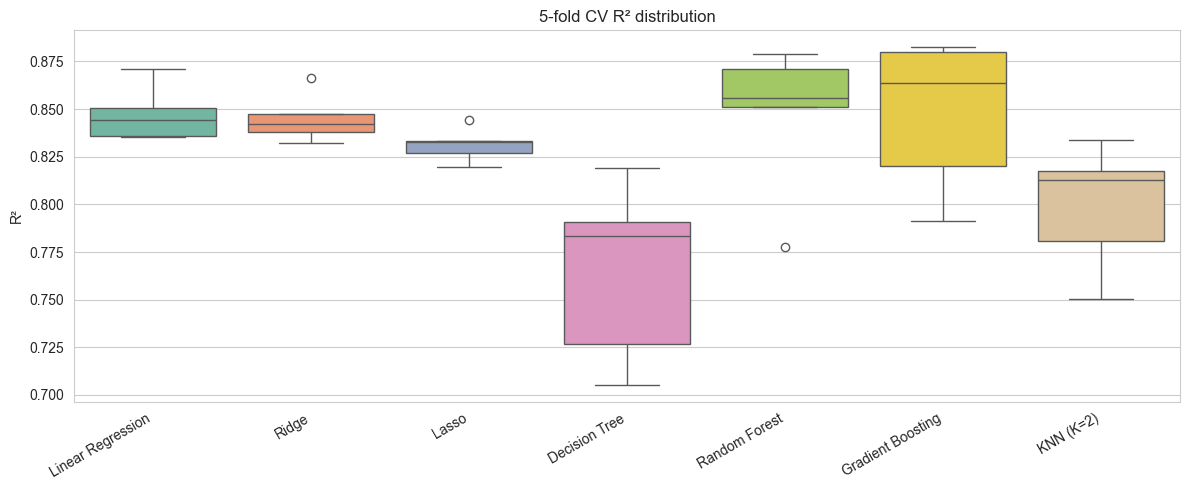

In [15]:
cv_df = pd.DataFrame(cv_scores)
plt.figure(figsize=(12, 5))
sns.boxplot(data=cv_df, palette="Set2")
plt.title("5-fold CV R² distribution")
plt.xticks(rotation=30, ha="right"); plt.ylabel("R²")
plt.tight_layout(); plt.show()

## 13. Hyperparameter Tuning — Random Forest

In [16]:
param_grid = {
    "n_estimators":      [200, 400, 600],
    "max_depth":         [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf":  [1, 2, 4],
}
grid = GridSearchCV(RandomForestRegressor(random_state=42, n_jobs=-1),
                    param_grid, cv=5, scoring="r2", n_jobs=-1)
grid.fit(X_train, y_train)
print(f"Best params : {grid.best_params_}")
print(f"Best CV R²  : {grid.best_score_:.4f}")

Best params : {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 600}
Best CV R²  : 0.8486



  Random Forest (Tuned)
  R2    : 0.9164
  RMSE  : 2.1201
  MAE   : 1.5901
  MAPE  : 0.0724


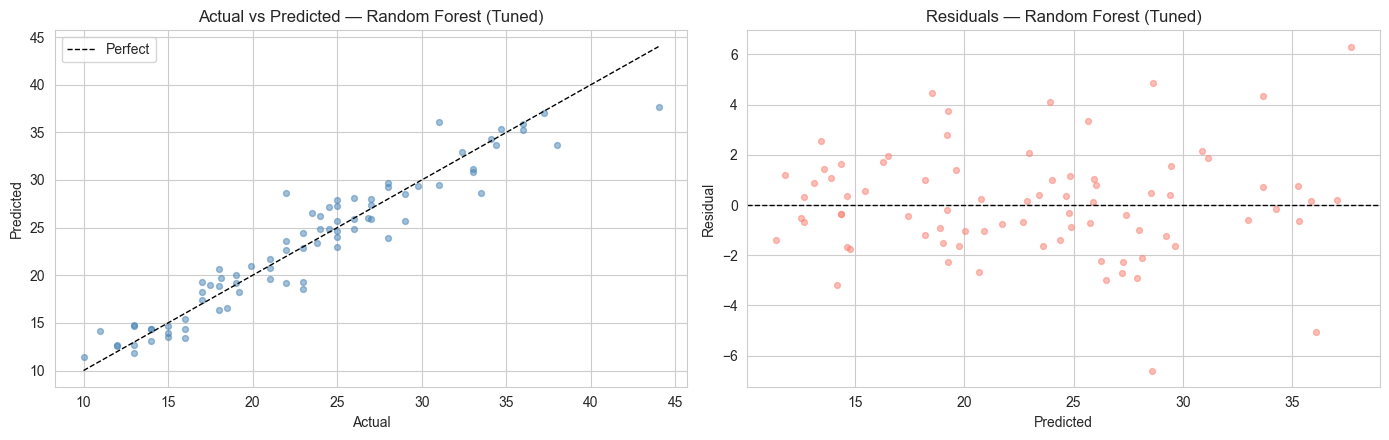

In [17]:
rf_tuned = grid.best_estimator_
pred_rf_t = rf_tuned.predict(X_test)
m_rf_t = evaluate_model("Random Forest (Tuned)", y_test, pred_rf_t)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
plot_actual_vs_predicted(y_test, pred_rf_t, "Random Forest (Tuned)", ax=axes[0])
plot_residuals(y_test, pred_rf_t, "Random Forest (Tuned)", ax=axes[1])
plt.tight_layout(); plt.show()

## 14. Tuned Feature Importance

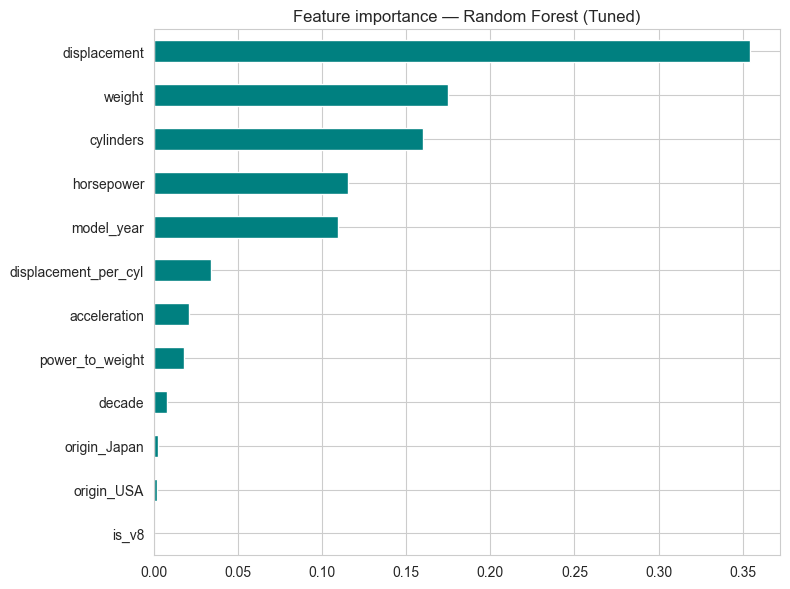

In [18]:
imp = pd.Series(rf_tuned.feature_importances_, index=X.columns).sort_values()
plt.figure(figsize=(8, 6))
imp.plot(kind="barh", color="teal")
plt.title("Feature importance — Random Forest (Tuned)")
plt.tight_layout(); plt.show()

## 15. Prediction Example

In [19]:
sample = X_test.iloc[[0, 1, 2]]
preds = rf_tuned.predict(sample)
for i, (idx, _) in enumerate(sample.iterrows()):
    actual = y_test.loc[idx]
    print(f"Sample {i}: actual={actual:.1f} mpg   predicted={preds[i]:.1f} mpg   error={preds[i]-actual:+.1f}")

Sample 0: actual=33.0 mpg   predicted=31.1 mpg   error=-1.9
Sample 1: actual=28.0 mpg   predicted=29.6 mpg   error=+1.6
Sample 2: actual=19.0 mpg   predicted=20.0 mpg   error=+1.0


## 16. Final Summary

| Aspect | Result |
|--------|--------|
| Best baseline by R² | Random Forest / Gradient Boosting (R² ≈ 0.88-0.90 typical) |
| Tuned model | Random Forest tuned via `GridSearchCV` |
| Top features | `weight`, `displacement`, `model_year`, `power_to_weight`, `horsepower` |
| Multicollinearity | Severe between weight / displacement / horsepower / cylinders — tree models handle it natively |

### Next Steps
- Try **gradient boosting with `model_year` interaction terms** in linear models for fairer comparison.
- Add **transmission type and gear count** if available (the original UCI release didn't include them).
- Visualize **partial dependence** on `weight` and `model_year` to show how MPG changes with each feature.